# Linear Regression Prototype
This notebook demonstrates how to use Linear Regression to mathematically define a trend and find pullbacks using RSI.

Testing Linear Regression Prototype on: 360ONE
Crunching Linear Regression...


Found 93 setup(s) matching criteria.


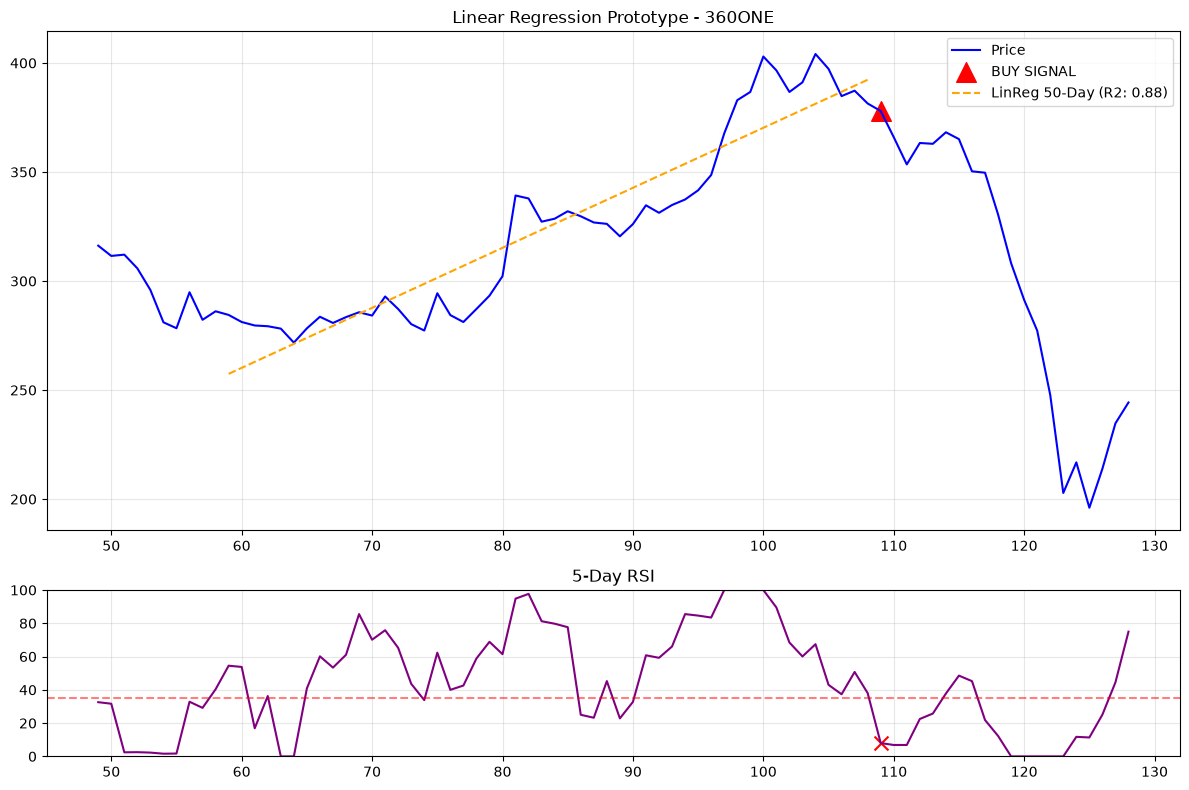

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import glob
import os
import warnings

# Suppress pandas warnings for cleaner output
warnings.filterwarnings('ignore')

# Configuration
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK_LR = 50
R2_THRESHOLD = 0.60
RSI_PERIOD = 5
RSI_THRESHOLD = 35

def calculate_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
if not all_files:
    print(f"No CSV files found in {DATA_DIR}")
else:
    file_path = all_files[0]
    stock_name = os.path.basename(file_path).split('.')[0]
    print(f"Testing Linear Regression Prototype on: {stock_name}")

    df = pd.read_csv(file_path)
    close_col = 'Close' if 'Close' in df.columns else 'close'
    
    df['RSI_5'] = calculate_rsi(df[close_col], RSI_PERIOD)
    df['LR_Slope'] = np.nan
    df['LR_R2'] = np.nan
    df['Signal'] = False

    x_time = np.arange(LOOKBACK_LR)

    print("Crunching Linear Regression...")
    for i in range(LOOKBACK_LR, len(df)):
        y_price = df[close_col].iloc[i - LOOKBACK_LR: i].values
        slope, intercept, r_value, p_value, std_err = linregress(x_time, y_price)
        
        df.at[i, 'LR_Slope'] = slope
        df.at[i, 'LR_R2'] = r_value ** 2

        is_uptrend = slope > 0
        is_smooth = (r_value ** 2) > R2_THRESHOLD
        is_pullback = df.at[i, 'RSI_5'] < RSI_THRESHOLD

        if is_uptrend and is_smooth and is_pullback:
            df.at[i, 'Signal'] = True

    signals = df[df['Signal'] == True]
    print(f"Found {len(signals)} setup(s) matching criteria.")

    if len(signals) > 0:
        signal_idx = signals.index[0]
        start_idx = max(0, signal_idx - LOOKBACK_LR - 10)
        end_idx = min(len(df), signal_idx + 20)
        
        plot_df = df.iloc[start_idx:end_idx]
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})
        
        ax1.plot(plot_df.index, plot_df[close_col], label='Price', color='blue')
        ax1.scatter(signal_idx, df.at[signal_idx, close_col], color='red', marker='^', s=200, label='BUY SIGNAL')
        
        y_price_sig = df[close_col].iloc[signal_idx - LOOKBACK_LR: signal_idx].values
        slope_sig, intercept_sig, _, _, _ = linregress(x_time, y_price_sig)
        reg_line = (slope_sig * x_time) + intercept_sig
        
        ax1.plot(range(signal_idx - LOOKBACK_LR, signal_idx), reg_line, color='orange', linestyle='--', 
                 label=f'LinReg 50-Day (R2: {df.at[signal_idx, "LR_R2"]:.2f})')
        
        ax1.set_title(f"Linear Regression Prototype - {stock_name}")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2.plot(plot_df.index, plot_df['RSI_5'], color='purple', label='RSI (5)')
        ax2.axhline(RSI_THRESHOLD, color='red', linestyle='--', alpha=0.5)
        ax2.scatter(signal_idx, df.at[signal_idx, 'RSI_5'], color='red', marker='x', s=100)
        ax2.set_title("5-Day RSI")
        ax2.set_ylim(0, 100)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("No signals found in this dataset to plot.")
